# Recreation of DUNL Paper Results 
## BIPN 162 Final Project

By Emily McClung, Naomi Ortega, and Isabel Rodriguez

This notebook contains the code for recreating a visualization from the paper "Interpretable deep learning for deconvolutional analysis of neural signals" by Tolooshams, B., Matias, S., Wu, H., Temereanca, S., Uchida, N., Murthy, V. N., Masset, P., & Ba, D (2025) https://doi.org/10.1016/j.neuron.2025.02.006. We recreate Figure 2D from their dopamine spiking experiment, which visualizes how the data analysis method they introduce, called Deconvolutional Unrolled Neural Learning (DUNL), learns interpretable event-related kernels capturing salience and value signals from dopamine neurons.
We recreate their resuslts using their experiment data zip
`dopamine-spiking-eshel-uchida.zip` that is available here: https://data.mendeley.com/datasets/rzfyr2886h/1 

## Setup
Import necessary packages and load the GitHub Repository containing the DUNL code.

In [2]:
#import necessary packages
import numpy as np
import torch
import sklearn
import h5py
import configmypy
import matplotlib.pyplot as plt

In [3]:
#Clone the DUNL algorithm GitHub Repository
!git clone https://github.com/btolooshams/dunl-compneuro.git

fatal: destination path 'dunl-compneuro' already exists and is not an empty directory.


In [3]:
#Import the DUNL code
import sys
sys.path.append("dunl-compneuro")
import dunl

In [5]:
!ls dunl-compneuro/dunl

__pycache__	     preprocess_scripts
boardfunc.py	     train_fiber_loop_acrossneurons.py
datasetloader.py     train_independentkernels_acrossneurons.py
lossfunc.py	     train_sharekernels_acrossneurons.py
model.py	     train_sharekernels_acrossneurons_groupneuralfirings.py
postprocess_scripts  utils.py


## Data Wrangling

* Include a clear explanation of the number of observations in the data and which observations (if any) are missing, and how this was handled.

In [54]:
#unzip the data from the zip file it comes as
!unzip dopamine-spiking-eshel-uchida.zip

Archive:  dopamine-spiking-eshel-uchida.zip
   creating: dopamine-spiking-eshel-uchida/
  inflating: dopamine-spiking-eshel-uchida/03_05_TT8_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt  
  inflating: dopamine-spiking-eshel-uchida/D_05-01_15-31-27_TT6_1_Common_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt  
  inflating: dopamine-spiking-eshel-uchida/10_26_TT7_2_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt  
  inflating: dopamine-spiking-eshel-uchida/D_05-14_14-16-28_TT3_1_Common_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt  
  inflating: dopamine-spiking-eshel-uchida/02_13_TT2_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt  
  inflating: dopamine-spiking-eshel-uchida/O_05-06_14-45-15_TT8_2_Common_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready

In [56]:
#see the names of all the files in the data folder
!ls dopamine-spiking-eshel-uchida

02_09_TT2_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
02_11_TT2_4_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
02_13_TT2_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
03_05_TT6_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
03_05_TT6_3_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
03_05_TT8_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
03_07_TT8_2_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
03_15_TT6_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
03_15_TT6_2_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
10_12_TT8_

In [25]:
#load one part of the data to look at what is contained in it
data = torch.load("dunl-compneuro/data/dopamine-spiking-eshel-uchida/02_09_TT2_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt")
print(data.keys())

#understanding the size of the raw data
print(data['raster'].size()) #This one file contains 150 trials of spike data from 1 neuron, and each trial contains 3100 time bins. (3100 bins X 25 ms = 77.5 seconds per trial) 

#understanding the size of the training data after preprocessing
print(data['y'].size()) # For each neuron, DUNL is trained on 124 time bins of 25 ms each, for 3.1 seconds per trial. There is a 3.1 second window containing the cue and reward events DUNL evaluates

dict_keys(['raster', 'time_org_resolution', 'time_bin_resolution', 'y', 'x', 'a', 'type'])
torch.Size([150, 1, 3100])
torch.Size([150, 1, 124])


In [26]:
#Tolooshams et al. used a sample of 40 neurons. Check how this dataset compares
files = os.listdir("dunl-compneuro/data/dopamine-spiking-eshel-uchida")
pt_files = [f for f in files if f.endswith(".pt")]
print(len(pt_files)) #There are 39 neuron files.

for f in pt_files[:40]:
    d = torch.load(f"dunl-compneuro/data/dopamine-spiking-eshel-uchida/{f}")
    print(d['raster'].shape) #The samples differ in how many trials were recorded in the session. 
                            # Since DUNL treats each neuron independently and the kernels are shared across neurons, this is no problem. 
                            # Importantly, the time dimension is consistent.

39
torch.Size([250, 1, 3100])
torch.Size([284, 1, 3100])
torch.Size([135, 1, 3100])
torch.Size([270, 1, 3100])
torch.Size([198, 1, 3100])
torch.Size([303, 1, 3100])
torch.Size([303, 1, 3100])
torch.Size([179, 1, 3100])
torch.Size([271, 1, 3100])
torch.Size([187, 1, 3100])
torch.Size([264, 1, 3100])
torch.Size([228, 1, 3100])
torch.Size([228, 1, 3100])
torch.Size([146, 1, 3100])
torch.Size([193, 1, 3100])
torch.Size([221, 1, 3100])
torch.Size([187, 1, 3100])
torch.Size([213, 1, 3100])
torch.Size([162, 1, 3100])
torch.Size([198, 1, 3100])
torch.Size([213, 1, 3100])
torch.Size([212, 1, 3100])
torch.Size([193, 1, 3100])
torch.Size([122, 1, 3100])
torch.Size([150, 1, 3100])
torch.Size([207, 1, 3100])
torch.Size([205, 1, 3100])
torch.Size([152, 1, 3100])
torch.Size([291, 1, 3100])
torch.Size([150, 1, 3100])
torch.Size([188, 1, 3100])
torch.Size([281, 1, 3100])
torch.Size([281, 1, 3100])
torch.Size([281, 1, 3100])
torch.Size([291, 1, 3100])
torch.Size([168, 1, 3100])
torch.Size([250, 1, 3100]

Inspecting the size of the contents of the data indicates that this data contains only 39 neurons, whereas Tolooshams et al. used 40. This will not affect the analysis, since DUNL learns shared kernels across neurons.

Understanding the keys contained in the data:
* Raster = Original spike train (DUNL does not train directly on these
* time_org_resolution = Original time resolution of the spike recording (time spacing of the raster spikes)
* time_bin_resolution = the time resolution used for binning the spikes. here, spikes occuring within 25 ms of each other are grouped into the same bin
* y = Binned spike counts
* x = Matrix of event timing (rewards)
* a = Restricts the model to activities within certain event windows to improve interpretability
* type = trial type/ reward condition

The data from the experiment in the paper are already in training format, such as the raw spike data being binned into 25 ms bins. The daata are ready to be used with DUNL. No further preprocessing is necessary.

In [14]:
#Move data into folder the algorithm expects
!mkdir -p dunl-compneuro/data
!mv dopamine-spiking-eshel-uchida dunl-compneuro/data/

Changes made to configurations in the dunl-compneuro repo:
1. In `config/dopamine_spiking_eshel_uchida_code122_kernel011_config.yaml/`
changed **from** `data_folder:  "../data/dopamine-spiking-eshel-uchida"`
**to** `data_folder: "dunl-compneuro/data/dopamine-spiking-eshel-uchida"`

2. In `dunl/train_sharekernels_acrossneurons.py` inside `init_params()`
 **commented out** `default="./dopamine_calcium_saramatias_uchida_config.yaml"`
and **uncommented** `default="./dopamine_spiking_eshel_uchida_code122_kernel011_config.yaml"` because we are running the dopamine spiking experiment on the dopamine spiking data, but this code contains configurations for the other experiments from their paper too. Later, we will use the calcium configuration when we apply DUNL to fiber photometry data.




## Running DUNL Analysis

In [63]:
##Run DUNL training to obtain learned event kernels from the data

In [20]:
!python dunl-compneuro/dunl/train_sharekernels_acrossneurons.py

Train DUNL on neural data.
device is cuda:0
init parameters.
Exp: dopaminespiking_25msbin_kernellength24_kernelnum3_code122_kernel011
create board.
create dataset and dataloader.
There 39 dataset in the folder.
dunl-compneuro/data/dopamine-spiking-eshel-uchida/10_26_TT6_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
x is shared among neurons. It is a function of trials, and number of kernels!
dunl-compneuro/data/dopamine-spiking-eshel-uchida/D_04-29_16-11-32_TT6_4_Common_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
x is shared among neurons. It is a function of trials, and number of kernels!
dunl-compneuro/data/dopamine-spiking-eshel-uchida/02_13_TT2_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
x is shared among neurons. It is a function of trials, and number of kernels!
dunl-compneuro/data/dopamine-spiking-eshel-uchida/O_05-06_14-45-15_TT8_2_Common

Training DUNL is complete. Now we will inspect the results.

In [22]:
import sys
sys.path.append("dunl-compneuro/dunl")

In [24]:
model = torch.load("rec_dunl_results/dopaminespiking_25msbin_kernellength24_kernelnum3_code122_kernel011_2026_03_08_20_00_52/model/model_final.pt")

In [25]:
print(model)
model.state_dict().keys()

DUNL1D(
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


odict_keys(['H', 'unrolling_alpha', 'code_sparse_regularization', 'code_pos_sided', 'code_neg_sided'])

H contains the learned kernels. We inspect the kernel tensor:

In [26]:
H = model.state_dict()['H']
print(H.shape) #There are 3 kernels, 1 channel, and 24 time bins. The 3 kernels matches the 3 kernels found in the paper.

torch.Size([3, 1, 24])


In [27]:
H_np = H.detach().cpu().numpy() #convert the kernels from a tensor to a numpy array

## Recreate Figure 2D 

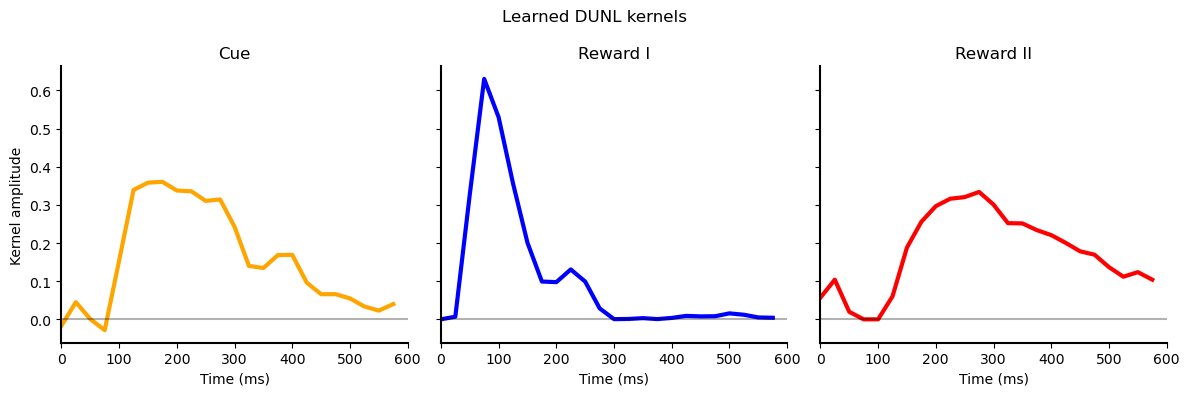

In [53]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(H_np.shape[2]) * 25  # ms

#create the 1 by 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(12,4), sharey=True)

labels = ["Cue", "Reward I", "Reward II"]
colors = ["orange", "blue", "red"]

# reorder kernels if necessary
kernels = [H_np[0,0], H_np[1,0], H_np[2,0]]

#plot the 3 kernels as 3 subplots
for i in range(3):
    axes[i].plot(time, kernels[i], color=colors[i], linewidth=3)
    axes[i].set_title(labels[i])
    axes[i].set_xlim(0,600)
    axes[i].set_xlabel("Time (ms)")

    #remove borders on top and right side of graph to match the style of the paper
    axes[i].spines['top'].set_visible(False) 
    axes[i].spines['right'].set_visible(False)
    #make axes lines bolder
    axes[i].spines['left'].set_linewidth(1.5)
    axes[i].spines['bottom'].set_linewidth(1.5)
    axes[i].axhline(y=0, color = 'black', linestyle='-', alpha = 0.3) #horizontal line at kernel amplitude = 0

axes[0].set_ylabel("Kernel amplitude")

plt.suptitle("Learned DUNL kernels")
plt.tight_layout()
plt.show()

## Figure Interpretation
Like in Tolooshams et al., DUNL learned 3 event-related kernels for the spiking data. Graphing the kernels showed that we successfully reproduced the results of their experiment. Figure 1 shows our replication of the figure. The kernels indicate the neuronal responses over time to distinct events, which were learned from the neural activity and the reward timing. 
* The Cue kernel corresponds to the neural activity during an odor cue which came before a reward was delivered.
* The Reward 1 kernel is for salience and is related to whether the reward was expected or unexpected.
* The Reward II kernel captures activity relating value of the reward, meaning it is correlated with the size of the reward (Tolooshams et al.).

One difference in our replication is that ours includes spikes at the beginning of each kernel. Tolooshams et al. noted that these initial spikes, which are salience-related, were removed from their window of analysis to improve how the size of the reward was represented. 
 
